# Caltech-256 Dataset

## 1. Import

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict
from datasets import load_dataset
import pandas as pd

## 2. Load Dataset

In [2]:
dataset = load_dataset("ilee0022/Caltech-256")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/452M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/471M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/119M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24791 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3061 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2755 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'text'],
        num_rows: 24791
    })
    test: Dataset({
        features: ['image', 'label', 'text'],
        num_rows: 3061
    })
    validation: Dataset({
        features: ['image', 'label', 'text'],
        num_rows: 2755
    })
})

In [3]:
train_ds = dataset["train"]
print("Total samples:", len(train_ds))
print("Features:", train_ds.features)

Total samples: 24791
Features: {'image': Image(mode=None, decode=True), 'label': Value('int64'), 'text': Value('string')}


## 3. Class distribution

In [ ]:
labels = [item['label'] for item in train_ds]
df = pd.DataFrame({"label": labels})

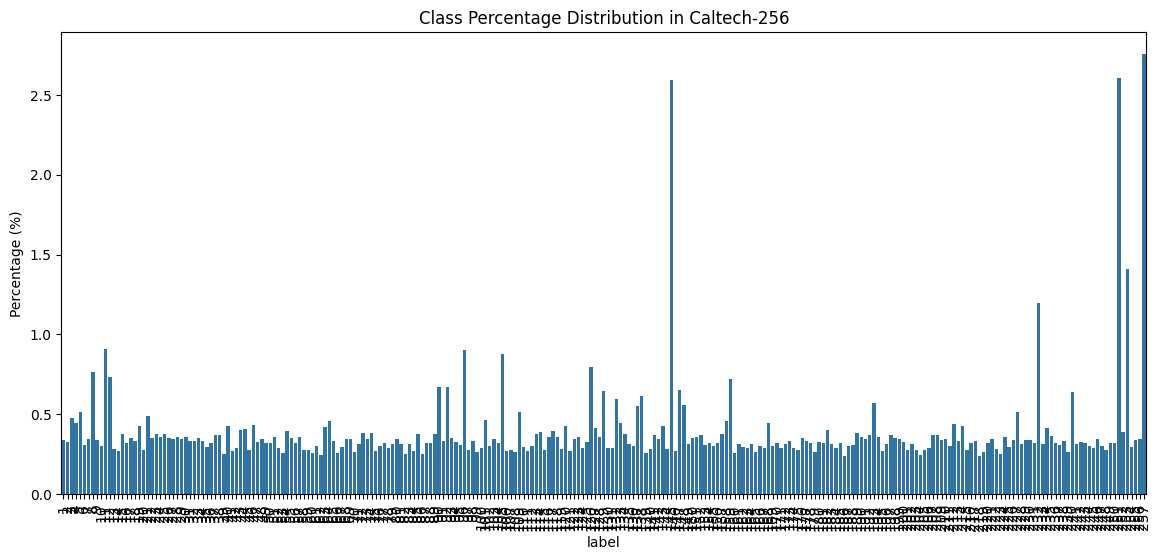

In [7]:
plt.figure(figsize=(14, 6))
sns.barplot(
    x=df['label'].value_counts().index,
    y=df['label'].value_counts(normalize=True).values * 100
)
plt.xticks(rotation=90)
plt.ylabel("Percentage (%)")
plt.title("Class Percentage Distribution in Caltech-256")
plt.show()

## 4. Visualize random images

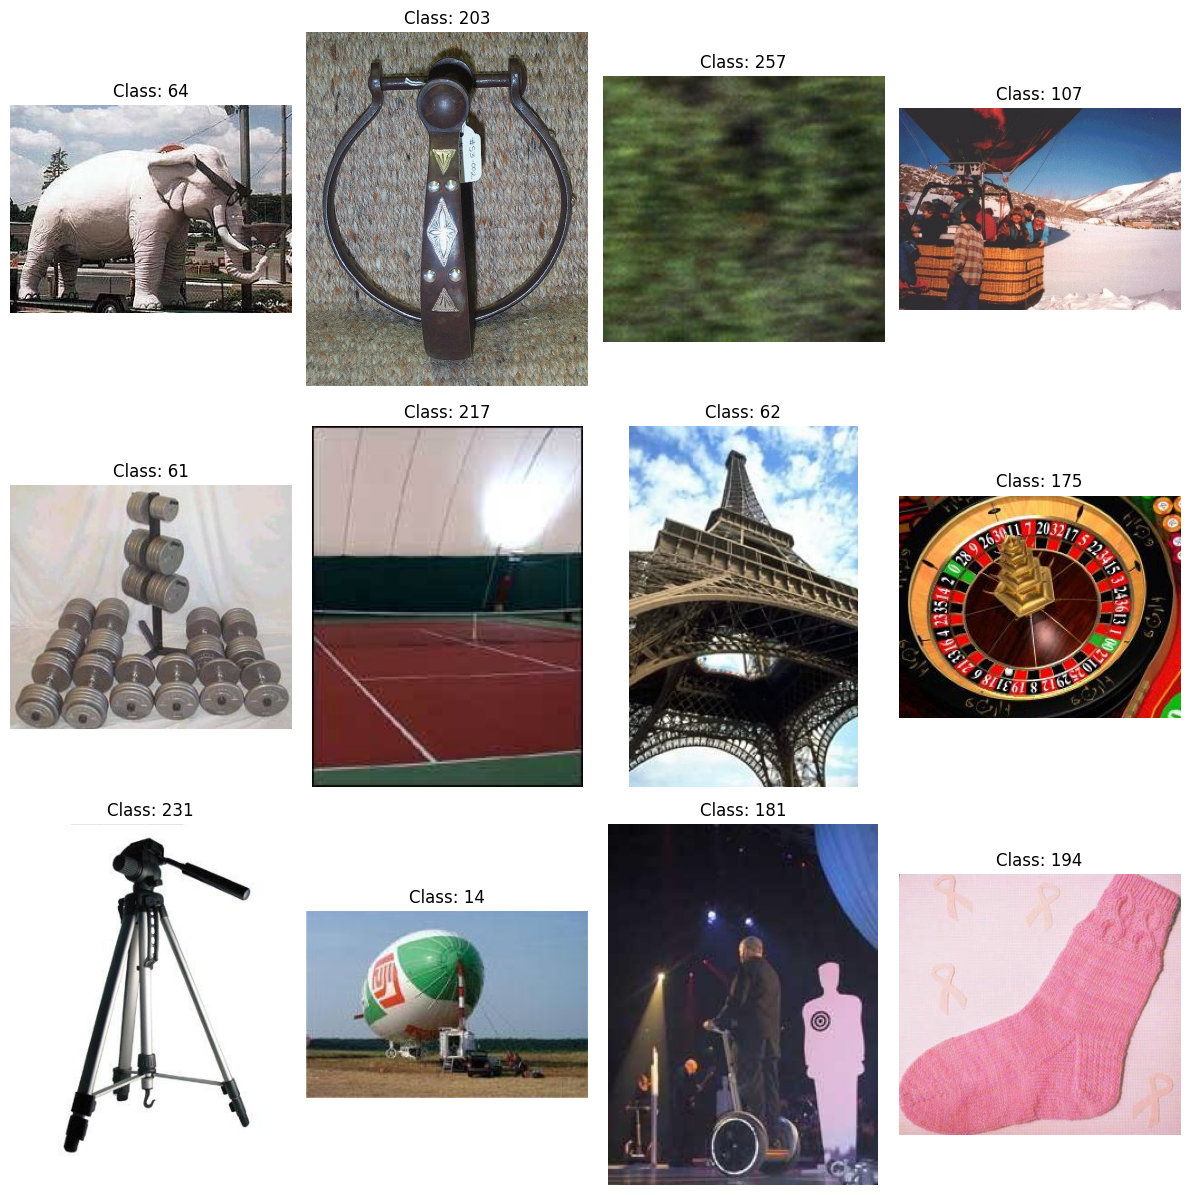

In [8]:
import random
import matplotlib.pyplot as plt

def show_random_images(n=12):
    plt.figure(figsize=(12, 12))
    indices = random.sample(range(len(train_ds)), n)

    for i, idx in enumerate(indices):
        sample = train_ds[idx]
        img = sample["image"]
        label = sample["label"]

        plt.subplot(3, 4, i+1)
        plt.imshow(img)
        plt.title(f"Class: {label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_images()

## 5. Analyze image sizes

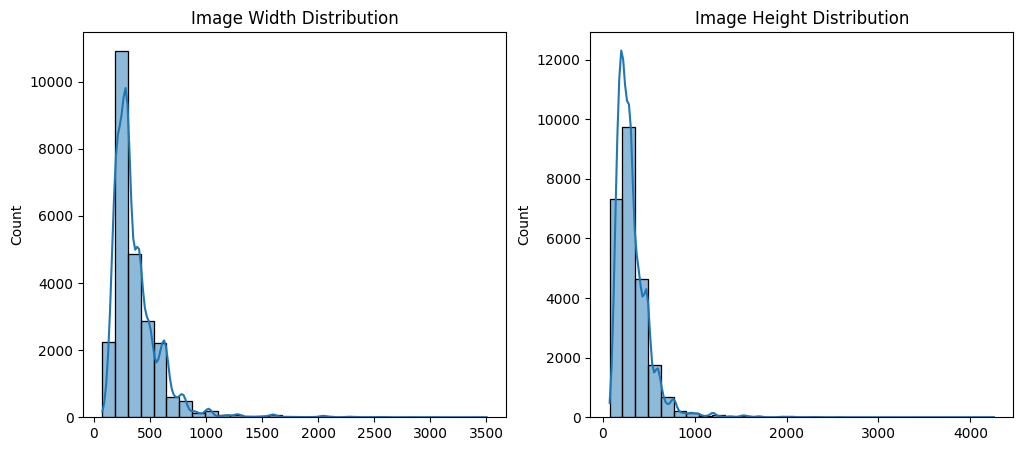

Average width: 371.1577992013231
Average height: 325.7685450365052


In [9]:
from PIL import Image
import numpy as np

widths, heights = [], []

for sample in train_ds:
    w, h = sample["image"].size
    widths.append(w)
    heights.append(h)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(widths, bins=30, kde=True)
plt.title("Image Width Distribution")

plt.subplot(1, 2, 2)
sns.histplot(heights, bins=30, kde=True)
plt.title("Image Height Distribution")

plt.show()

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

## 6. Aspect ratio analysis

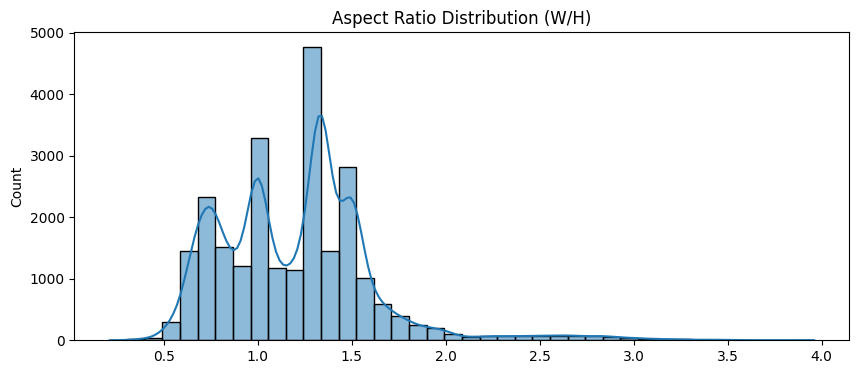

Average aspect ratio: 1.2056100836418326


In [10]:
aspect_ratios = np.array(widths) / np.array(heights)

plt.figure(figsize=(10, 4))
sns.histplot(aspect_ratios, bins=40, kde=True)
plt.title("Aspect Ratio Distribution (W/H)")
plt.show()

print("Average aspect ratio:", np.mean(aspect_ratios))